# Estimation on a different population: adult heights

*Part 2 · Lesson 11 · another dataset  ·  data: NHANES adult-male heights*

*↩ A companion to [Lesson 11: Estimation & standard error](11-estimation.ipynb).*

**↩ Back:** [Lesson 11: Estimation & standard error](11-estimation.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it →](11-estimation~the-code.ipynb)

The core lesson learned the standard error on a **strongly right-skewed** population: the living areas of
Ames homes, where a few mansions stretch a long tail to the right. There, the cloud of sample-mean
estimates only became a tidy bell thanks to the **Central Limit Theorem** (CLT).

Here we run the *same investigation* on a population with the opposite personality: the heights of about
**5,000 US adult men**, measured by the **NHANES** health survey (National Health and Nutrition
Examination Survey, 2015–2018, ages 20 and over). Heights are large in number and **already nearly
normal** — a gentle symmetric hump, almost no skew. The payoff is the lesson's punchline: the
standard-error machinery (**SE = σ/√n**, the **√n law**, unbiasedness) is *exactly the same* and matches
*just as exactly*, whether the population is lopsided or tidy. You don't have to "wait for the CLT" here —
but the formula didn't need the CLT to be true in the first place. Run each grey cell with
**Shift + Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

NHANES_URL = ('https://bpb-us-e1.wpmucdn.com/sites.psu.edu/dist/4/27975/files/'
              '2023/09/NHANES15-18_menAge20YearsAndOver.csv')
nh = sl.load_csv('nhanes_men.csv', url=NHANES_URL)

# The height column 'BMXHT' is recorded in MILLIMETRES. Divide by 10 to get
# centimetres (e.g. 1845.0 mm -> 184.5 cm), then drop any missing values.
height_cm = (nh['BMXHT'].dropna() / 10.0)

# Treat ALL of these men as the population, so we get to KNOW the true answer.
population = height_cm.to_numpy()                # height (cm) of every man in the survey
MU    = population.mean()                          # the TRUE population mean  (mu)
SIGMA = population.std(ddof=0)                     # the TRUE population stdev (sigma)
N_POP = len(population)

print(f'Population: {N_POP:,} adult men (standing height, cm)')
print(f'TRUE population mean   mu    = {MU:.2f} cm   <- the answer we will try to estimate')
print(f'TRUE population stdev  sigma = {SIGMA:.2f} cm')
print(f'population skew              = {stats.skew(population):+.3f}   (near 0 -> nearly normal)')

Population: 5,092 adult men (standing height, cm)
TRUE population mean   mu    = 173.26 cm   <- the answer we will try to estimate
TRUE population stdev  sigma = 7.82 cm
population skew              = -0.071   (near 0 -> nearly normal)


## 0) A note on units — millimetres to centimetres

Real datasets rarely arrive in the units you'd reach for. NHANES stores standing height as **`BMXHT` in
millimetres**, so a stored value of `1845.0` means **1845 mm**. Dividing by 10 turns that into the
friendlier **184.5 cm** (a hair over six feet), which is why the setup did
`height_cm = nh['BMXHT'].dropna() / 10.0` once, up front. Always check a dataset's units before you trust
its averages — an unconverted "mean height of 1733" is alarming until you realise it's millimetres.

Notice the numbers above: about **5,000 men**, a true mean near **173 cm**, a standard deviation near
**7.8 cm**, and a **skew of about −0.07** — so close to zero that the population is essentially symmetric.
That near-zero skew is the whole point of this companion lesson: unlike the lopsided Ames homes of the
core, *this* population is already a near-perfect bell before we ever take a sample.

## 1) Parameter vs. statistic — the two kinds of number

The whole game of inference rests on telling apart two numbers that look similar but mean very
different things.

- A **parameter** is a number that describes the **whole population**. It is **fixed** but usually
  **unknown** — in real life you can't measure everyone. Greek letters: the population mean is $\mu$
  ("mu"), the population standard deviation is $\sigma$ ("sigma"), a population proportion is $p$.
- A **statistic** is a number computed from a **sample**. It is **known** (you have the data) but
  **random** — measure a different sample of men and you'd get a different value. Roman letters: the
  sample mean is $\bar{x}$ ("x-bar"), the sample standard deviation is $s$, a sample proportion is
  $\hat{p}$ ("p-hat").

> **The mantra:** *parameters are fixed and unknown; statistics are random and known.* We use the
> statistic we *can* see to estimate the parameter we *can't*.

Our setup is special on purpose: because we declared all ~5,000 men the population, we know the parameter
$\mu \approx 173$ cm. In a real study you would **never** know this — you'd measure a few dozen men and
guess. Here we know it so we can *check* whether our methods actually work.

In [2]:
# A statistic is what we compute from a SAMPLE. Let's grab one sample of 50 men.
rng = np.random.default_rng(11)          # change this seed to draw a different sample
n = 50
# Draw each man independently, allowing repeats (replace=True): treat these men as an
# endless super-population, so sigma/sqrt(n) is the EXACT target for the standard error later on.
sample = rng.choice(population, size=n, replace=True)

xbar = sample.mean()                       # the STATISTIC: our estimate of mu
s    = sample.std(ddof=1)                   # sample standard deviation (note ddof=1)
print(f'Sample of n = {n} men')
print(f'  sample mean  x-bar = {xbar:.2f} cm   (our estimate)')
print(f'  true mean    mu    = {MU:.2f} cm   (the target)')
print(f'  we missed by       = {xbar - MU:+.2f} cm')

Sample of n = 50 men
  sample mean  x-bar = 173.05 cm   (our estimate)
  true mean    mu    = 173.26 cm   (the target)
  we missed by       = -0.21 cm


## 2) A statistic is an *estimator*

When we use the sample mean $\bar{x}$ to *stand in for* the unknown population mean $\mu$, we are using
it as an **estimator** — a recipe that turns sample data into a guess about a parameter. The single
number it produces (like the ~173 cm above) is a **point estimate**: one best guess, a single point on
the number line.

| Parameter (unknown truth) | Estimator (the recipe) | Point estimate (one number) |
|---|---|---|
| population mean $\mu$ | sample mean $\bar{x}$ | e.g. 173.4 cm |
| population proportion $p$ | sample proportion $\hat{p}$ | e.g. 0.16 |
| population stdev $\sigma$ | sample stdev $s$ | e.g. 7.9 cm |

The same idea works for a **proportion**. Suppose we care about the share of "tall" men (say, over
185 cm — roughly 6 ft 1 in). The parameter $p$ is the true share in the whole population; the estimator
is the sample proportion $\hat{p}$ = (tall men in the sample) / (sample size).

In [3]:
# p-hat estimates p, exactly as x-bar estimates mu.
tall = 185                                  # call a man "tall" if height > 185 cm
p_true = (population > tall).mean()          # the PARAMETER p (we know it here)
p_hat  = (sample > tall).mean()              # the STATISTIC  p-hat (our estimate)

print(f'TRUE proportion of men over {tall} cm :  p     = {p_true:.3f}')
print(f'Sample estimate from our 50 men      :  p-hat = {p_hat:.3f}')
print(f'\nBoth x-bar->mu and p-hat->p are point estimates: one number guessing a parameter.')

TRUE proportion of men over 185 cm :  p     = 0.063
Sample estimate from our 50 men      :  p-hat = 0.080

Both x-bar->mu and p-hat->p are point estimates: one number guessing a parameter.


## 3) Bias vs. precision — the dartboard

A single estimate is one dart thrown at a board whose bullseye is the true parameter $\mu$. To judge an
estimator we throw *many* darts (take many samples) and ask two separate questions:

- **Bias (accuracy):** do the darts *center* on the bullseye, or are they systematically pulled to one
  side? An estimator is **unbiased** if, averaged over all possible samples, it lands exactly on the
  truth — its long-run average equals the parameter. The sample mean $\bar{x}$ is unbiased for $\mu$.
- **Precision (spread):** how *tightly* do the darts cluster? A precise estimator gives nearly the same
  answer every time; an imprecise one is all over the board. We measure this spread with the **standard
  error** (next section).

These are independent. You can be:

| | tight cluster (precise) | wide cluster (imprecise) |
|---|---|---|
| **centered on truth (unbiased)** | best case: accurate *and* reliable | right on average, but any one shot is shaky |
| **off-center (biased)** | reliably *wrong* (the dangerous case!) | wrong *and* shaky |

Let's throw the darts. We'll draw **3,000 samples**, compute $\bar{x}$ from each, and see where they land.

In [4]:
n = 50
n_samples = 3000
xbars = np.array([rng.choice(population, size=n, replace=True).mean()
                  for _ in range(n_samples)])

print(f'Drew {n_samples:,} samples of n = {n}.')
print(f'Average of all the sample means : {xbars.mean():.2f} cm')
print(f'True population mean mu          : {MU:.2f} cm')
print(f'Difference (the bias)           : {xbars.mean() - MU:+.3f} cm   <- essentially 0: UNBIASED')

Drew 3,000 samples of n = 50.
Average of all the sample means : 173.27 cm
True population mean mu          : 173.26 cm
Difference (the bias)           : +0.008 cm   <- essentially 0: UNBIASED


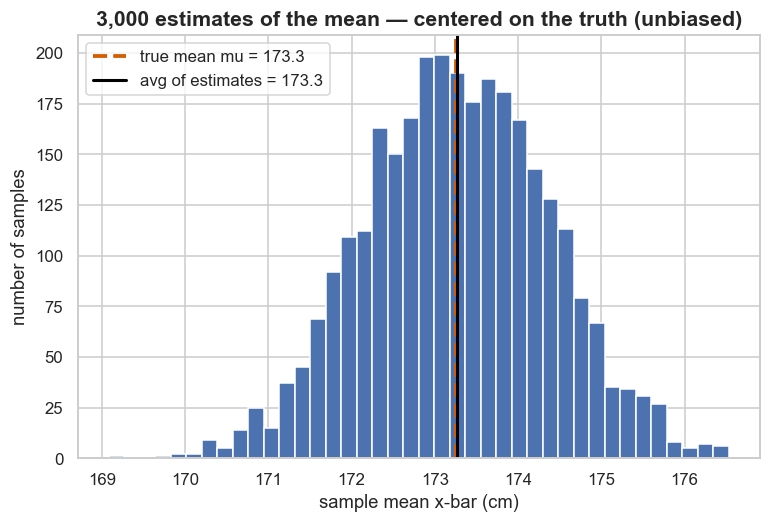

In [5]:
# The dartboard, drawn as a histogram of where x-bar lands.
fig, ax = plt.subplots()
ax.hist(xbars, bins=40, color='#4c72b0', edgecolor='white')
ax.axvline(MU, color='#D55E00', lw=2.5, ls='--', label=f'true mean mu = {MU:.1f}')
ax.axvline(xbars.mean(), color='black', lw=2, label=f'avg of estimates = {xbars.mean():.1f}')
ax.set_xlabel('sample mean x-bar (cm)'); ax.set_ylabel('number of samples')
ax.set_title(f'{n_samples:,} estimates of the mean — centered on the truth (unbiased)')
ax.legend(); plt.show()

The cloud of estimates piles up **right on top of** the true mean (the black "average of estimates" line
sits essentially on the red "truth" line). That's what **unbiased** looks like: no systematic pull to
either side.

Here is the first contrast with the core lesson. There, the population of house sizes was strongly
right-skewed, so a *single* house tells you little about the shape of this bell — the symmetric,
bell-shaped cloud of $\bar{x}$ was a **gift of the CLT**, which kicks in only once the sample is big
enough. Our height population is **already** a near-perfect bell, so the cloud of $\bar{x}$ comes out
symmetric and bell-shaped even at this modest $n = 50$, with nothing to "wait for." Same dartboard,
calmer population. The *width* of the cloud — how far a typical dart lands from center — is the thing we
quantify next.

## 4) The standard error — the typical miss

The **standard error (SE)** of an estimator is just the **standard deviation of its sampling
distribution** — that cloud of estimates we just drew. In plain words:

> **The standard error is the typical distance between one sample's estimate and the true parameter.**

It is the number that turns "my estimate is off by *some* amount" into "my estimate is off by *about
this much*." For the sample mean, theory gives a beautifully simple formula:

$$\text{SE}(\bar{x}) \;=\; \frac{\sigma}{\sqrt{n}}$$

But there's a catch: in real life we don't know $\sigma$ (that's a population parameter!). So we
**estimate** the standard error by swapping in the sample standard deviation $s$:

$$\widehat{\text{SE}}(\bar{x}) \;=\; \frac{s}{\sqrt{n}}$$

This $s/\sqrt{n}$ is what calculators and textbooks call "the standard error." Let's prove it's right
the only way that really convinces anyone — by **simulation**. We already have 3,000 sample means; their
*actual* spread should match $\sigma/\sqrt{n}$.

In [6]:
empirical_SE = xbars.std(ddof=0)            # the ACTUAL spread of our 3,000 estimates
formula_SE   = SIGMA / np.sqrt(n)           # the textbook prediction sigma/sqrt(n)

print(f'Empirical SE  (spread of the 3,000 x-bars) = {empirical_SE:.3f} cm')
print(f'Formula   SE  (sigma / sqrt(n))            = {formula_SE:.3f} cm')
print(f'They match to within {abs(empirical_SE - formula_SE):.3f} cm  ->  the formula is REAL.')

Empirical SE  (spread of the 3,000 x-bars) = 1.104 cm
Formula   SE  (sigma / sqrt(n))            = 1.106 cm
They match to within 0.001 cm  ->  the formula is REAL.


The simulated spread and the formula $\sigma/\sqrt{n}$ agree to a hair. This is the heart of the
companion's message: in the core, the population was wildly skewed and the formula *still* matched
exactly; here the population is tidy and near-normal and the formula matches *just as exactly*. The
standard-error formula does **not** depend on the population being bell-shaped — that's a separate gift of
the CLT, which governs the *shape* of the cloud, not its *width*. The width is $\sigma/\sqrt{n}$ either
way.

Now the **practical** version: in a real study you have **one** sample, not 3,000. You don't know
$\sigma$, so you use $s/\sqrt{n}$. Does that single-sample estimate of the SE land near the truth?

In [7]:
# In real life you get ONE sample and must estimate the SE from it alone.
one_sample = rng.choice(population, size=n, replace=True)
s_one  = one_sample.std(ddof=1)
SE_hat = s_one / np.sqrt(n)                  # estimated standard error, from one sample

print(f'From a single sample of n = {n}:')
print(f'  sample mean  x-bar       = {one_sample.mean():.2f} cm')
print(f'  estimated SE = s/sqrt(n) = {SE_hat:.3f} cm')
print(f'  (true SE = sigma/sqrt(n) = {formula_SE:.3f} cm, so our one-sample guess is close)')
print(f'\nReport it as:  mu is about {one_sample.mean():.1f} cm, give or take ~{SE_hat:.1f} cm.')

From a single sample of n = 50:
  sample mean  x-bar       = 173.45 cm
  estimated SE = s/sqrt(n) = 1.080 cm
  (true SE = sigma/sqrt(n) = 1.106 cm, so our one-sample guess is close)

Report it as:  mu is about 173.5 cm, give or take ~1.1 cm.


### Standard deviation vs. standard error — don't mix them up

This trips up almost everyone, so let's nail it:

- **Standard deviation ($s$ or $\sigma$)** describes the spread of the **individual data points** — how
  much one *man's* height differs from another. It does **not** shrink as you collect more data; men are
  as varied in height as they ever were.
- **Standard error ($s/\sqrt{n}$)** describes the spread of the **estimate** — how much the *sample mean*
  would differ from sample to sample. It **shrinks** as $n$ grows, because averaging more men steadies
  the average.

Same units (cm), completely different jobs. The SD answers "how varied are the men?"; the SE answers
"how trustworthy is my average?"

In [8]:
print(f'Spread of individual MEN  (sample SD, s)      = {s_one:.2f} cm   <- big; heights vary a lot')
print(f'Spread of the AVERAGE     (standard error)    = {SE_hat:.2f} cm   <- small; averaging steadies it')
print(f'\nThe SE is smaller than s by a factor of sqrt(n) = sqrt({n}) = {np.sqrt(n):.1f}.')

Spread of individual MEN  (sample SD, s)      = 7.63 cm   <- big; heights vary a lot
Spread of the AVERAGE     (standard error)    = 1.08 cm   <- small; averaging steadies it

The SE is smaller than s by a factor of sqrt(n) = sqrt(50) = 7.1.


## 5) The $\sqrt{n}$ law — quadruple the sample, halve the error

Look hard at $\text{SE} = \sigma/\sqrt{n}$. The sample size sits under a **square root**. That single
detail governs the entire economics of data collection:

- To make your estimate **twice as precise** (cut the SE in half), you don't need *twice* the data — you
  need **four times** as much ($\sqrt{4} = 2$).
- For **10 times** the precision, you need **100 times** the data ($\sqrt{100} = 10$).

This is the law of *diminishing returns* in sampling: each extra data point helps, but later ones help
less than earlier ones. Let's watch the SE shrink as $n$ climbs — and confirm the simulated spread tracks
the $1/\sqrt{n}$ curve. (Because heights are already near-normal, the dots will sit on the curve at *every*
$n$, even the smallest — there's no "too small for the CLT" wobble to worry about.)

In [9]:
sizes = [10, 25, 50, 100, 200, 400, 800]
rows = []
for nn in sizes:
    means = np.array([rng.choice(population, size=nn, replace=True).mean() for _ in range(2000)])
    rows.append({'n': nn,
                 'empirical_SE': means.std(ddof=0),
                 'formula_SE': SIGMA / np.sqrt(nn)})
se_table = pd.DataFrame(rows)
print(se_table.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

print(f'\nNotice: going from n=50 to n=200 (4x the data) roughly HALVES the SE:')
se50  = se_table.loc[se_table['n'] == 50,  'formula_SE'].iloc[0]
se200 = se_table.loc[se_table['n'] == 200, 'formula_SE'].iloc[0]
print(f'  SE at n=50  = {se50:.2f} cm')
print(f'  SE at n=200 = {se200:.2f} cm   (about half — quadrupling n halved the error)')

  n  empirical_SE  formula_SE
 10         2.464       2.472
 25         1.606       1.564
 50         1.143       1.106
100         0.787       0.782
200         0.545       0.553
400         0.382       0.391
800         0.273       0.276

Notice: going from n=50 to n=200 (4x the data) roughly HALVES the SE:
  SE at n=50  = 1.11 cm
  SE at n=200 = 0.55 cm   (about half — quadrupling n halved the error)


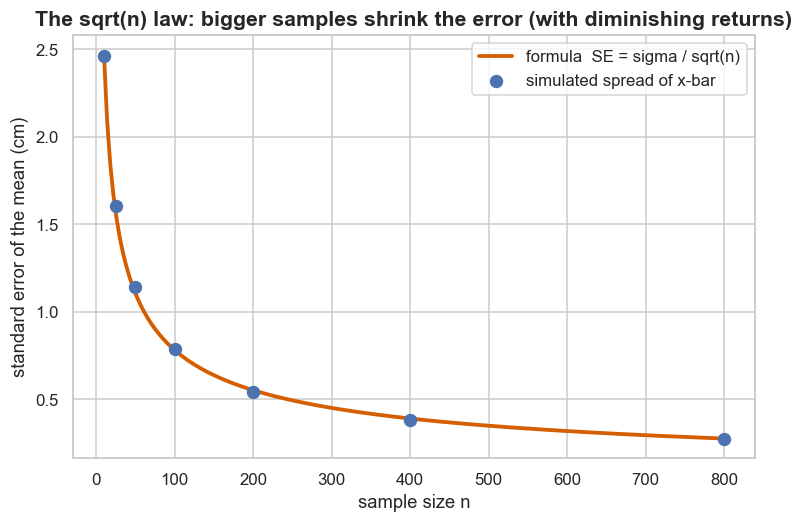

In [10]:
# Picture the sqrt(n) law: dots = simulation, smooth curve = sigma/sqrt(n).
nn_grid = np.linspace(10, 800, 200)
fig, ax = plt.subplots()
ax.plot(nn_grid, SIGMA / np.sqrt(nn_grid), color='#D55E00', lw=2.5,
        label=r'formula  SE = sigma / sqrt(n)')
ax.scatter(se_table['n'], se_table['empirical_SE'], s=60, color='#4c72b0', zorder=5,
           label='simulated spread of x-bar')
ax.set_xlabel('sample size n'); ax.set_ylabel('standard error of the mean (cm)')
ax.set_title('The sqrt(n) law: bigger samples shrink the error (with diminishing returns)')
ax.legend(); plt.show()

The simulated dots fall right on the $\sigma/\sqrt{n}$ curve, and the curve flattens out: the drop from
$n=10$ to $n=100$ is dramatic, but from $n=400$ to $n=800$ it's barely visible. That flattening is the
$\sqrt{n}$ law telling you when more data stops being worth the cost — identical to what the skewed Ames
population showed, because the $\sqrt{n}$ law is a fact about the *formula*, not about the shape of the
data.

## 6) From standard error to the margin of error (a bridge)

The standard error is the engine; the **margin of error** is what gets *reported*. A point estimate
alone is overconfident — it pretends we hit the bullseye exactly. Instead we surround it with a cushion:

$$\text{estimate} \;\pm\; (\text{a multiplier}) \times \text{SE}.$$

That "$\text{multiplier} \times \text{SE}$" piece is the **margin of error**. For roughly 95%
confidence the multiplier is about **2** (it comes from the bell curve — see the normal-distribution and
Central Limit Theorem lessons), so a rough 95% interval is

$$\bar{x} \;\pm\; 2\,\frac{s}{\sqrt{n}}.$$

Stretching the point estimate into a *range* like this gives the **confidence interval**. Let's build a
quick one — then leave the full story (where the "2" really comes from, what "95% confidence" honestly
means, and a 100-interval coverage demo) to **the confidence-interval flagship**, the very next stop.

In [11]:
estimate = one_sample.mean()
moe = 2 * SE_hat                            # rough 95% margin of error  (~2 * SE)
lo, hi = estimate - moe, estimate + moe

print(f'Point estimate  : x-bar = {estimate:.1f} cm')
print(f'Margin of error : +/- {moe:.1f} cm   ( ~2 * SE )')
print(f'Rough 95% interval: ({lo:.1f}, {hi:.1f}) cm')
print(f'True mean mu      : {MU:.2f} cm  ->  {"inside" if lo <= MU <= hi else "outside"} our interval')
print('\nNext lesson: what "95% confidence" really means, and why the multiplier is ~2.')

Point estimate  : x-bar = 173.5 cm
Margin of error : +/- 2.2 cm   ( ~2 * SE )
Rough 95% interval: (171.3, 175.6) cm
True mean mu      : 173.26 cm  ->  inside our interval

Next lesson: what "95% confidence" really means, and why the multiplier is ~2.


## Now you try

Predict what will happen *before* you run each change:

1. **Shrink the sample.** In the section-3/4 cells, set `n = 10` and re-run. Does the histogram of
   estimates get **wider** or narrower? Does the empirical SE still match $\sigma/\sqrt{n}$? (It should —
   and notice the cloud stays bell-shaped even at $n = 10$, because *this* population is already normal,
   unlike the skewed Ames homes in the core.)

2. **Test the $\sqrt{n}$ law by hand.** The SE at `n = 50` is printed above. Predict the SE at
   `n = 800` *before looking* — divide the `n=50` value by $\sqrt{800/50} = \sqrt{16} = 4$. Then check it
   against the table in section 5.

3. **Estimate a proportion instead of a mean.** In a new cell, draw a sample and compute `p-hat` for
   "men over 185 cm" the way section 2 does, but do it **2,000 times** and take the standard deviation of
   all the `p-hat` values. That spread is the standard error of a *proportion*. (Bonus: it should be close
   to $\sqrt{p(1-p)/n}$ — the proportion's own SE formula.)

4. **Change the seed.** Swap `np.random.default_rng(11)` for any other number. Your single point estimate
   moves, but does the *standard error* (the typical miss) change much? Why or why not?

## What you learned

- A **parameter** describes the whole population (fixed, unknown, Greek: $\mu$, $\sigma$, $p$); a
  **statistic** is computed from a sample (random, known, Roman: $\bar{x}$, $s$, $\hat{p}$).
- A statistic used to guess a parameter is an **estimator**; the single number it gives is a **point
  estimate** ($\bar{x}$ estimates $\mu$; $\hat{p}$ estimates $p$).
- **Bias** is whether estimates *center* on the truth (accuracy); **precision** is how *tightly* they
  cluster (spread). The sample mean is **unbiased** — we saw 3,000 estimates pile up right on $\mu$.
- The **standard error** is the typical distance from estimate to truth — the standard deviation of the
  sampling distribution. For a mean it is $\sigma/\sqrt{n}$, estimated in practice by $s/\sqrt{n}$, and
  simulation confirmed the formula exactly.
- **Standard deviation** measures the spread of individual data points and doesn't shrink with $n$;
  **standard error** measures the spread of the *estimate* and shrinks like $1/\sqrt{n}$.
- The **$\sqrt{n}$ law**: quadruple the sample to halve the error — real but with diminishing returns.
- **The big contrast:** the core ran all of this on a strongly *right-skewed* population (Ames home
  sizes), where the bell-shaped sampling distribution was the **CLT's** doing; here the population of
  heights is *already near-normal*, so the cloud is bell-shaped from the start. Yet the SE formula, the
  $\sqrt{n}$ law and unbiasedness held **identically** — the standard-error machinery doesn't care
  whether the population is tidy or skewed.
- **Margin of error** $\approx 2 \times \text{SE}$ stretches a point estimate into a range — the bridge
  to the confidence-interval flagship coming next.

---

**↩ Back to the lesson:** [Lesson 11: Estimation & standard error](11-estimation.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [The code behind it](11-estimation~the-code.ipynb)